In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [14]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def softmax(logits, tau=1.0):
    z = logits / max(tau, 1e-8)
    z = z - np.max(z)
    expz = np.exp(z)
    return expz / np.sum(expz)


def cosine_similarity_matrix(M, eps=1e-12):
    norms = np.linalg.norm(M, axis=1, keepdims=True) + eps
    U = M / norms
    return U @ U.T


class LexiconGrowthSim:
    def __init__(
        self,
        n_words=80,
        n_contexts=80,
        d=25,
        seed=7,
        # exposure
        zipf_s=1.1,
        caregiver_noise=0.05,
        # respondent learning (increased)
        alpha=0.16,
        resp_temp=1.0,
        # operant learning (increased)
        eta=0.06,
        tau=0.8,
        baseline_lr=0.01,
        p_succ=0.9,
        p_fail=0.1,
        # acquisition thresholds
        gamma_L=0.75,
        gamma_S=0.25,
        # input realism: semantic structure of caregiver "mistakes"
        semantic_noise_temp=0.5,
        # child-directed bias: prob of sampling context near already-acquired words
        cds_bias=0.0,
    ):
        assert n_words == n_contexts, "Minimal version assumes 1 canonical context per word."
        self.rng = np.random.default_rng(seed)

        self.n_words = n_words
        self.n_contexts = n_contexts
        self.d = d

        X = self.rng.normal(0, 1, size=(n_contexts, d))
        X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
        self.X = X

        self.canonical_word = np.arange(n_contexts)

        ranks = np.arange(1, n_contexts + 1)
        p = 1.0 / (ranks ** zipf_s)
        p = p / p.sum()
        self.context_probs = p

        self.caregiver_noise = caregiver_noise
        self.semantic_noise_temp = semantic_noise_temp
        self.cds_bias = cds_bias
        self._cached_L_acq = np.zeros(n_words, dtype=bool)
        self.alpha = alpha
        self.resp_temp = resp_temp
        self.eta = eta
        self.tau = tau
        self.baseline_lr = baseline_lr
        self.p_succ = p_succ
        self.p_fail = p_fail
        self.gamma_L = gamma_L
        self.gamma_S = gamma_S

        self.A = np.zeros((n_words, d))
        self.Theta = np.zeros((n_words, d))
        self.baseline = 0.0

    def sample_context(self):
        if self.cds_bias <= 0 or not self._cached_L_acq.any():
            return self.rng.choice(self.n_contexts, p=self.context_probs)
        if self.rng.random() < self.cds_bias:
            anchor_ctxs = np.where(self._cached_L_acq)[0]
            sim = self.X @ self.X[anchor_ctxs].mean(axis=0)
            sim = np.clip(sim, 0, None)
            if sim.sum() > 1e-12:
                p_ctx = sim / sim.sum()
                return self.rng.choice(self.n_contexts, p=p_ctx)
        return self.rng.choice(self.n_contexts, p=self.context_probs)

    def caregiver_utterance(self, ctx):
        w_star = self.canonical_word[ctx]
        if self.rng.random() < self.caregiver_noise:
            x = self.X[ctx]
            logits = self.X @ x
            logits[w_star] = -np.inf
            p_sub = softmax(logits, tau=max(self.semantic_noise_temp, 1e-8))
            return self.rng.choice(self.n_words, p=p_sub)
        return w_star

    def respondent_update(self, w_heard, x):
        logits = (self.A @ x) / max(self.resp_temp, 1e-8)
        p_w = softmax(logits, tau=1.0)
        x_hat = p_w @ self.A
        self.A[w_heard] += self.alpha * (x - x_hat)

    def operant_policy(self, x):
        logits = self.Theta @ x
        return softmax(logits, tau=self.tau)

    def operant_step(self, ctx, x):
        pi = self.operant_policy(x)
        w = self.rng.choice(self.n_words, p=pi)
        w_star = self.canonical_word[ctx]
        if w == w_star:
            r = 1.0 if self.rng.random() < self.p_succ else 0.0
        else:
            r = 1.0 if self.rng.random() < self.p_fail else 0.0

        self.baseline = (1 - self.baseline_lr) * self.baseline + self.baseline_lr * r
        adv = r - self.baseline

        onehot = np.zeros(self.n_words)
        onehot[w] = 1.0
        grad = (onehot - pi)[:, None] * x[None, :]
        self.Theta += self.eta * adv * grad

        return r

    def comprehension(self):
        return sigmoid(self.A @ self.X.T)

    def speaker_probs(self):
        logits = self.Theta @ self.X.T
        logits = logits / max(self.tau, 1e-8)
        logits = logits - np.max(logits, axis=0, keepdims=True)
        expz = np.exp(logits)
        return expz / np.sum(expz, axis=0, keepdims=True)

    def acquisition_status(self):
        comp = self.comprehension()
        spk = self.speaker_probs()
        diag_comp = comp[np.arange(self.n_words), np.arange(self.n_contexts)]
        diag_spk = spk[np.arange(self.n_words), np.arange(self.n_contexts)]
        L_acq = diag_comp >= self.gamma_L
        S_acq = diag_spk >= self.gamma_S
        return L_acq, S_acq

    def build_network_stats(self, cos_threshold=0.25):
        if nx is None:
            return np.nan, np.nan, 0
        C = cosine_similarity_matrix(self.A)
        np.fill_diagonal(C, 0.0)
        edges = np.argwhere(C >= cos_threshold)
        G = nx.Graph()
        G.add_nodes_from(range(self.n_words))
        G.add_edges_from((int(i), int(j)) for i, j in edges if i < j)
        degrees = [deg for _, deg in G.degree()]
        mean_degree = float(np.mean(degrees)) if degrees else 0.0
        clustering = float(nx.average_clustering(G)) if G.number_of_edges() > 0 else 0.0
        return mean_degree, clustering, G.number_of_edges()

    def run(self, n_steps=100000, log_every=1000, cos_threshold=0.25):
        logs = {
            "t": [],
            "reward_rate": [],
            "L_size": [],
            "S_size": [],
            "mean_degree": [],
            "clustering": [],
            "n_edges": [],
            "L_first_step": None,
            "S_first_step": None,
        }
        L_first_step = np.full(self.n_words, np.nan)
        S_first_step = np.full(self.n_words, np.nan)
        reward_window = []
        for step in range(1, n_steps + 1):
            ctx = self.sample_context()
            x = self.X[ctx]

            w_heard = self.caregiver_utterance(ctx)
            self.respondent_update(w_heard, x)

            r = self.operant_step(ctx, x)
            reward_window.append(r)
            if len(reward_window) > log_every:
                reward_window.pop(0)

            if step % log_every == 0:
                L_acq, S_acq = self.acquisition_status()
                self._cached_L_acq = L_acq
                for w in np.where(L_acq)[0]:
                    if np.isnan(L_first_step[w]):
                        L_first_step[w] = step
                for w in np.where(S_acq)[0]:
                    if np.isnan(S_first_step[w]):
                        S_first_step[w] = step
                md, cl, ne = self.build_network_stats(cos_threshold=cos_threshold)

                logs["t"].append(step)
                logs["reward_rate"].append(float(np.mean(reward_window)))
                logs["L_size"].append(int(L_acq.sum()))
                logs["S_size"].append(int(S_acq.sum()))
                logs["mean_degree"].append(md)
                logs["clustering"].append(cl)
                logs["n_edges"].append(ne)

        logs["L_first_step"] = L_first_step
        logs["S_first_step"] = S_first_step
        return logs


def plot_logs(logs):
    t = np.array(logs["t"])

    # 1) Lexicon growth: remove union, log-like scaling on y
    plt.figure()
    plt.plot(t, logs["L_size"], label="Listener")
    plt.plot(t, logs["S_size"], label="Speaker")
    plt.xlabel("Steps")
    plt.ylabel("Words acquired")
    plt.yscale("symlog", linthresh=1)  # handles zeros but behaves like log for larger values
    plt.legend()
    plt.title("Lexicon Growth (symlog y-axis)")

    # 2) Instrumental performance
    plt.figure()
    plt.plot(t, logs["reward_rate"])
    plt.xlabel("Steps")
    plt.ylabel("Reward rate (windowed)")
    plt.title("Instrumental Performance")

    # 3) Network stats: always computed at log points, plus edge count to show non-blank
    plt.figure()
    plt.plot(t, logs["mean_degree"], label="Mean degree")
    plt.plot(t, logs["clustering"], label="Clustering")
    plt.plot(t, logs["n_edges"], label="# Edges")
    plt.xlabel("Steps")
    plt.ylabel("Statistic")
    plt.legend()
    plt.title("Emergent Semantic Network Statistics")

    plt.show()

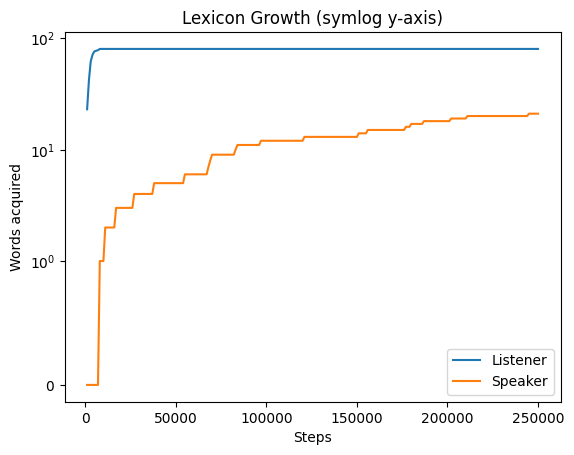

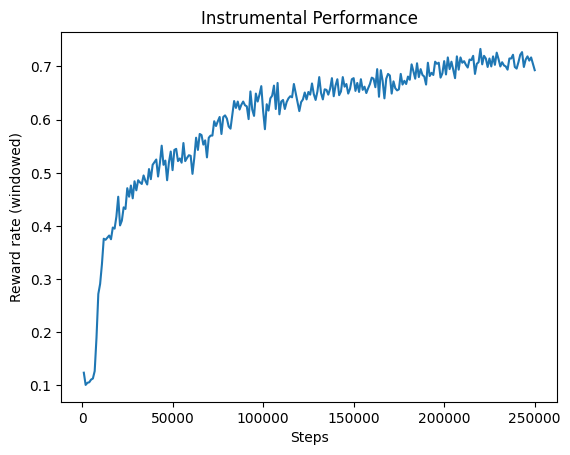

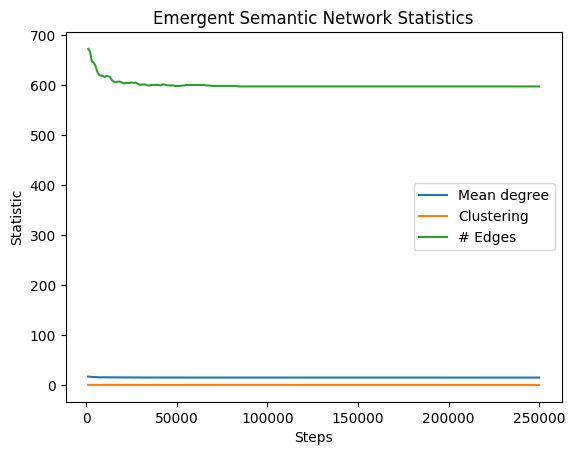

In [15]:
sim = LexiconGrowthSim()
logs = sim.run(n_steps=250_000, log_every=1000, cos_threshold=0.15)
plot_logs(logs)